# Convolutional  Neural  Network (CNN)

- Image Classification / Identification

    - pixels size and RGB values
    - we have images highest value is 255 and lowest value is 0


- Object Detection
    

Convolutional Neural Networks(CNN) are class of deep neural networks commonly used in `image recognition` and `processing`

In [3]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

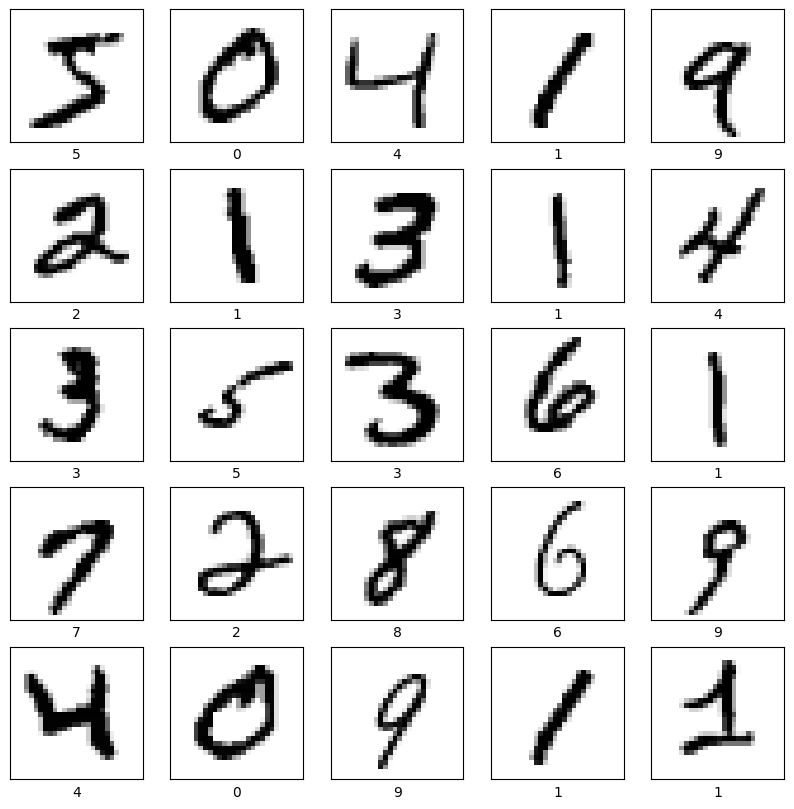

In [4]:
# Laod dataset
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()   # X_train means images and y_train means labels

# Display some images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i],cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

In [5]:
# Explore the data set
print(f"we have {len(X_train)}  images in train set and {len(X_test)} images in test set")
print(f"Each image is of shape {X_train[0].shape}")

we have 60000  images in train set and 10000 images in test set
Each image is of shape (28, 28)


In [6]:
X_train.shape  #image

(60000, 28, 28)

In [7]:
y_train.shape  #label 

(60000,)

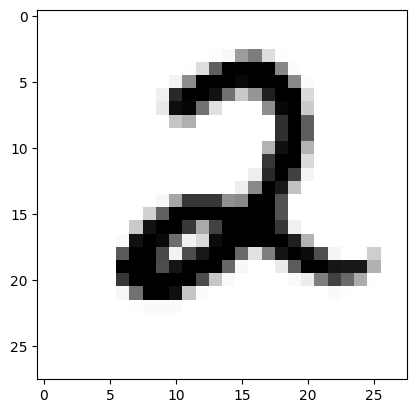

In [8]:
plt.imshow(X_train[3333],cmap=plt.cm.binary)

# Each TimeRandom Image

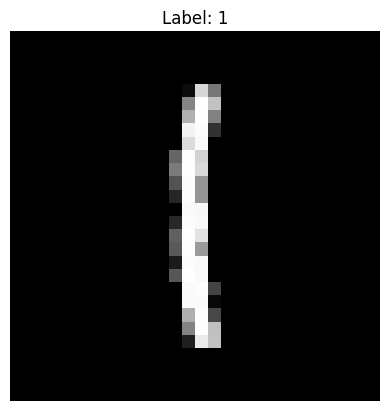

In [26]:
import random

# Select a random image from the training set
random_image = random.randint(0, len(X_train) - 1)

# Reshape the flattened image (784,) to (28, 28)
plt.imshow(X_train[random_image].reshape(28, 28), cmap="gray")

plt.title(f"Label: {y_train[random_image]}")
plt.axis("off")
plt.show()

In [28]:
# normalize the data to be between 0 and 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [11]:
# Display the value of each pixel in the image after normalization
print("pixel values of the first image after normalization:")
for row in X_train[0]:
    for pixel in row:
        print("{:.2f}".format(pixel), end=" ")
    print()
# Reshape the data to be 1D arrays of size 784 (28x28)
X_train = X_train.reshape((len(X_train), 28 * 28))
X_test = X_test.reshape((len(X_test), 28 * 28))
# Display the complete output of the first image after reshaping

pixel values of the first image after normalization:
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.01 0.07 0.07 0.07 0.49 0.53 0.69 0.10 0.65 1.00 0.97 0.50 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.12 0.14 0.37 0.60 0.67 0.99 0.99 0.99 0.99 0.99 0.88 0.67 0

# Build the model

In [12]:
import tensorflow as tf
from tensorflow.keras import layers

# create an input layer
input_layer = tf.keras.layers.Input(shape=(28, 28, 1)) # 28x28 pixel images with a single color channel

# CNN model building

model = tf.keras.Sequential([
    input_layer, # input layer
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer 
    # filter is the number of filters we want to apply
    # kernel is the size of window/filter moving over the image
    layers.Conv2D(filters=10, kernel_size=(3, 3),  activation='relu'), # convolutional layer
    layers.MaxPooling2D(), # pooling layer
    
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer
    layers.MaxPooling2D(), # pooling layer
    
    layers.Flatten(), # flatten layer
    layers.Dense(10, activation='softmax') # output layer # why did we add 10?
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 10)       │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,440 (17.34 KB)

 Trainable params: 4,440 (17.34 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# grab an image
img = X_test[0]
print(img.shape)

# rehape the image to (28, 28, 1)
img = img.reshape((28, 28, 1))
print(img.shape)

(784,)
(28, 28, 1)


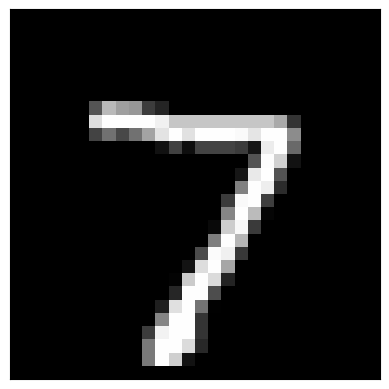

In [14]:
plt.imshow(img, cmap="gray")
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.show()

In [15]:
# predict the image
predictions = model.predict(img.reshape(1, 28, 28, 1))
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
[[0.12065221 0.10620677 0.07635413 0.11594845 0.07717283 0.10263729
  0.0960286  0.10065769 0.10171831 0.10262379]]


In [16]:
print(predictions[:,7])

[0.10065769]


In [17]:
print(f"The model predicts that this image is a {predictions.argmax()}.")

The model predicts that this image is a 0.


- Through data augmentation we can get more accuracy in image analysis but handwritten digits are not affected by data augmentation bcz 6 become 9 and 9 become 6   